In [1]:
import numpy as np
import pandas as pd

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [3]:
df = sns.load_dataset("mpg")
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    str    
 8   name          398 non-null    str    
dtypes: float64(4), int64(3), str(2)
memory usage: 28.1 KB


In [5]:
print(df.columns)

Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'model_year', 'origin', 'name'],
      dtype='str')


In [6]:
df.drop(columns=["name"], inplace=True, errors="ignore")
# df.drop(columns=["name"], axis=1, inplace=True)
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
0,18.0,8,307.0,130.0,3504,12.0,70,usa
1,15.0,8,350.0,165.0,3693,11.5,70,usa
2,18.0,8,318.0,150.0,3436,11.0,70,usa
3,16.0,8,304.0,150.0,3433,12.0,70,usa
4,17.0,8,302.0,140.0,3449,10.5,70,usa


**summary of dataset**

In [7]:
df.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


**Data processing**

In [8]:
df.isnull().sum()

mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
dtype: int64

In [9]:
df[df.isnull().any(axis=1)]

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
32,25.0,4,98.0,NaN,2046,19.0,71,usa
126,21.0,6,200.0,NaN,2875,17.0,74,usa
330,40.9,4,85.0,NaN,1835,17.3,80,europe
336,23.6,4,140.0,NaN,2905,14.3,80,usa
354,34.5,4,100.0,NaN,2320,15.8,81,europe
374,23.0,4,151.0,NaN,3035,20.5,82,usa


In [10]:
df.dropna(inplace=True)

In [11]:
df.isnull().sum().any()

np.False_

In [12]:
df.shape

(392, 8)

**Univriate Analysis**

In [13]:
df.cylinders.unique()

array([8, 4, 6, 3, 5])

In [14]:
df.cylinders.value_counts()

cylinders
4    199
8    103
6     83
3      4
5      3
Name: count, dtype: int64

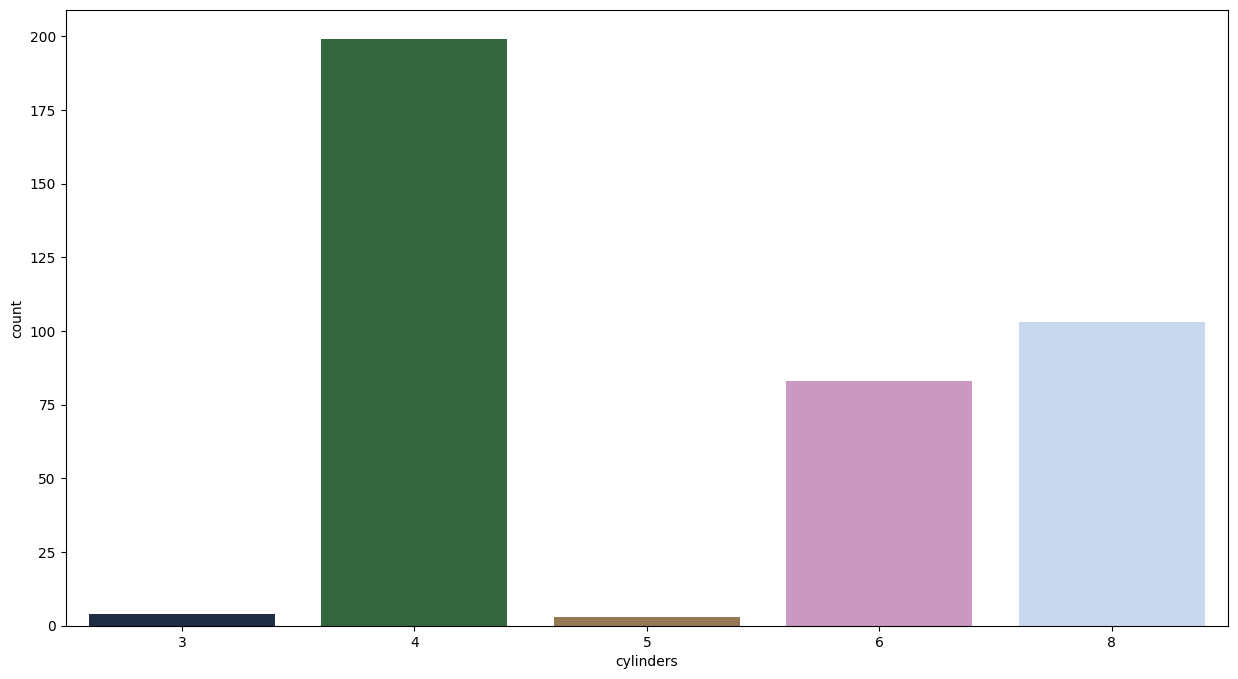

In [15]:
plt.figure(figsize=(15, 8))
sns.countplot(x="cylinders", data=df, palette="cubehelix")
plt.show()

In [16]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
0,18.0,8,307.0,130.0,3504,12.0,70,usa
1,15.0,8,350.0,165.0,3693,11.5,70,usa
2,18.0,8,318.0,150.0,3436,11.0,70,usa
3,16.0,8,304.0,150.0,3433,12.0,70,usa
4,17.0,8,302.0,140.0,3449,10.5,70,usa


In [17]:
df["model_year"] = (1900 + df.model_year)

In [18]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
0,18.0,8,307.0,130.0,3504,12.0,1970,usa
1,15.0,8,350.0,165.0,3693,11.5,1970,usa
2,18.0,8,318.0,150.0,3436,11.0,1970,usa
3,16.0,8,304.0,150.0,3433,12.0,1970,usa
4,17.0,8,302.0,140.0,3449,10.5,1970,usa


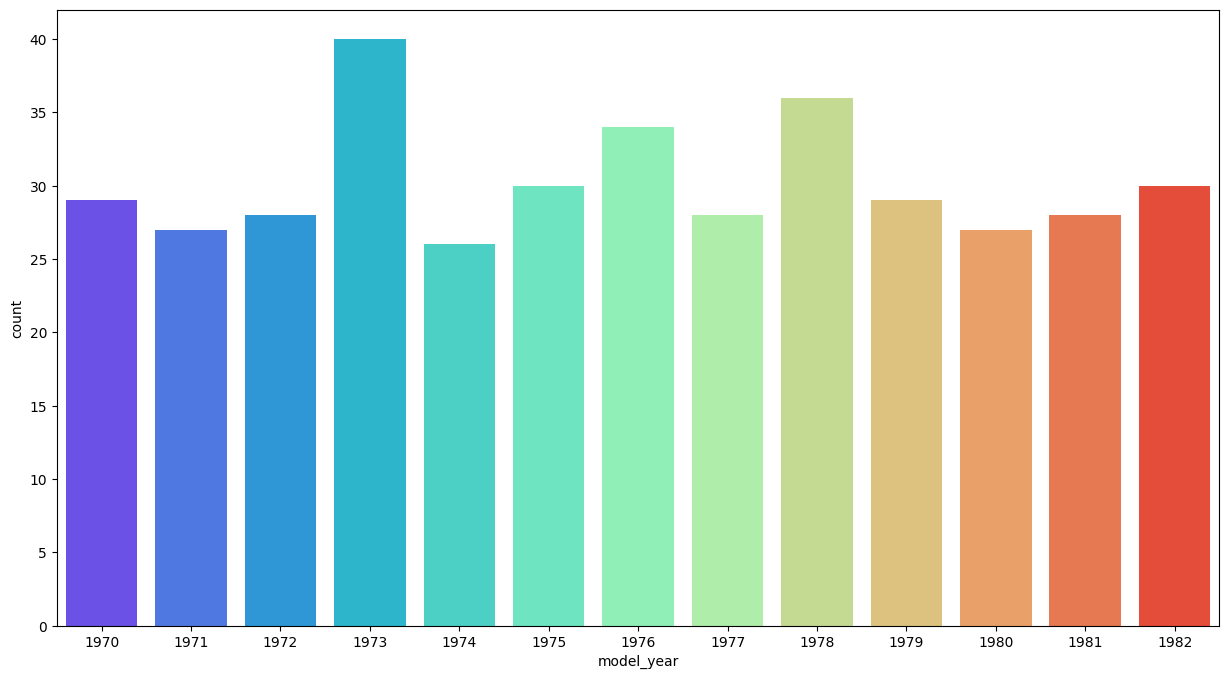

In [19]:
plt.figure(figsize=(15, 8))
sns.countplot(x="model_year", data=df, palette="rainbow")
plt.show()

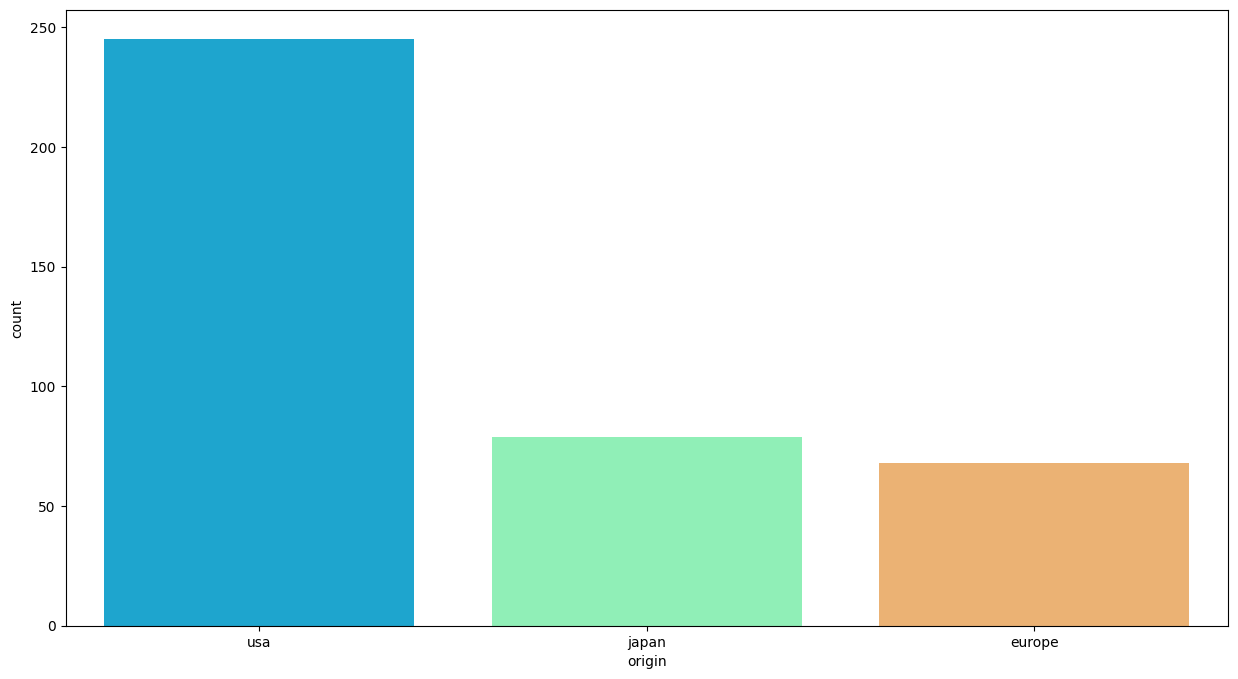

In [20]:
plt.figure(figsize=(15, 8))
sns.countplot(x="origin", data=df, palette="rainbow")
plt.show()

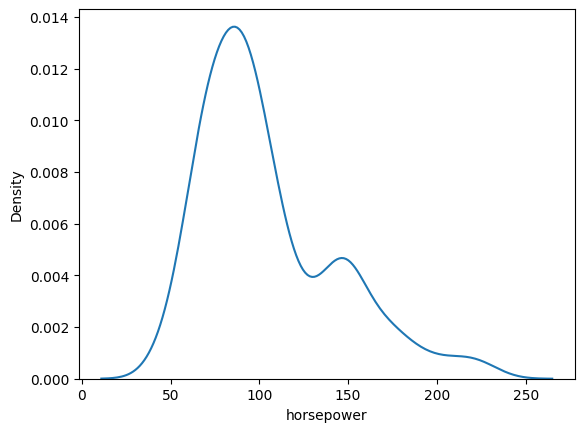

In [21]:
sns.kdeplot(df["horsepower"])
plt.show()

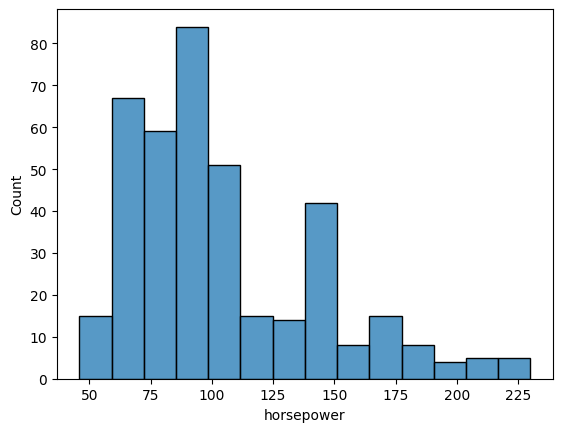

In [22]:
sns.histplot(df["horsepower"])
plt.show()

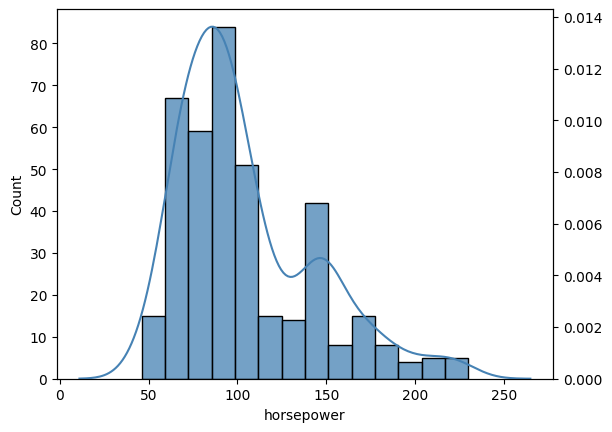

In [23]:
fig, ax = plt.subplots()

sns.histplot(df["horsepower"], kde=False, color="steelblue", ax=ax)

# Use the second y-axis twin so KDE scale doesn't conflict
ax2 = ax.twinx()
sns.kdeplot(df["horsepower"], color="steelblue", ax=ax2)
ax2.set_ylabel("")  # hide the right y-axis label

plt.show()

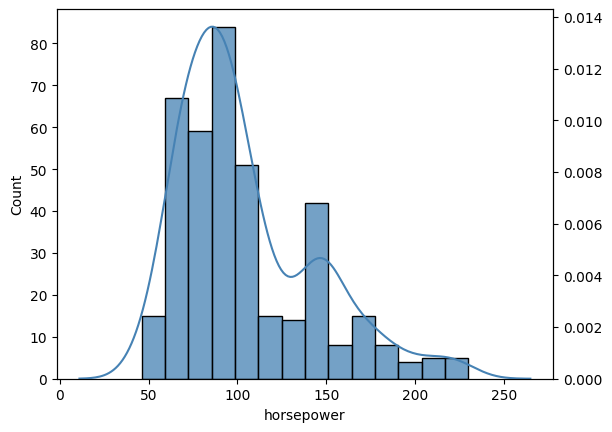

In [24]:
fig, ax = plt.subplots()

sns.histplot(df["horsepower"], kde=False, color="steelblue", ax=ax)

# Use the second y-axis twin so KDE scale doesn't conflict
ax2 = ax.twinx()
sns.kdeplot(df["horsepower"], color="steelblue", ax=ax2)
ax2.set_ylabel("")  # hide the right y-axis label

plt.show()

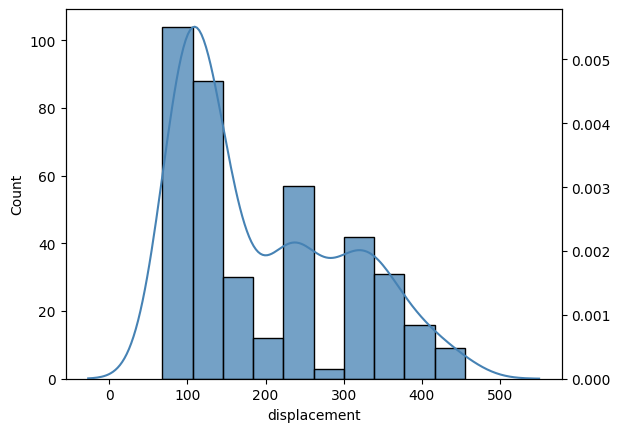

In [25]:
fig, ax = plt.subplots()

sns.histplot(df["displacement"], kde=False, color="steelblue", ax=ax)

# Use the second y-axis twin so KDE scale doesn't conflict
ax2 = ax.twinx()
sns.kdeplot(df["displacement"], color="steelblue", ax=ax2)
ax2.set_ylabel("")  # hide the right y-axis label

plt.show()

**Bivariate Analysis**

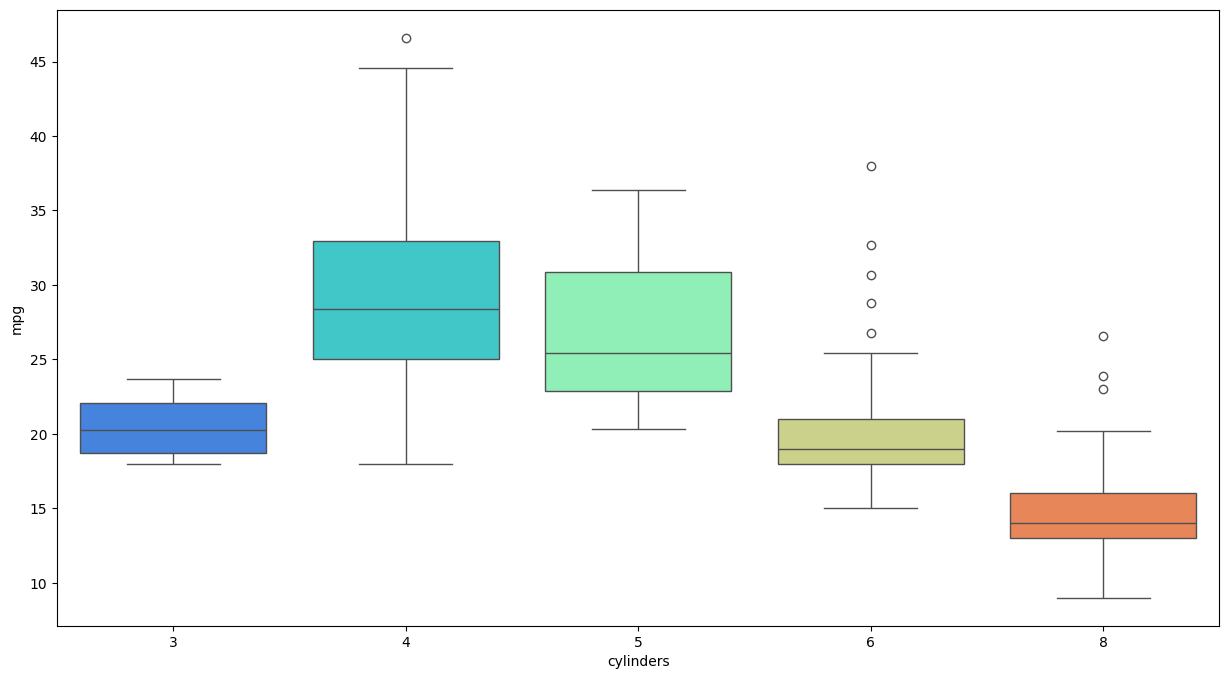

In [26]:
plt.figure(figsize=(15, 8))
sns.boxplot(x="cylinders", y="mpg", data=df, palette="rainbow")
plt.show()

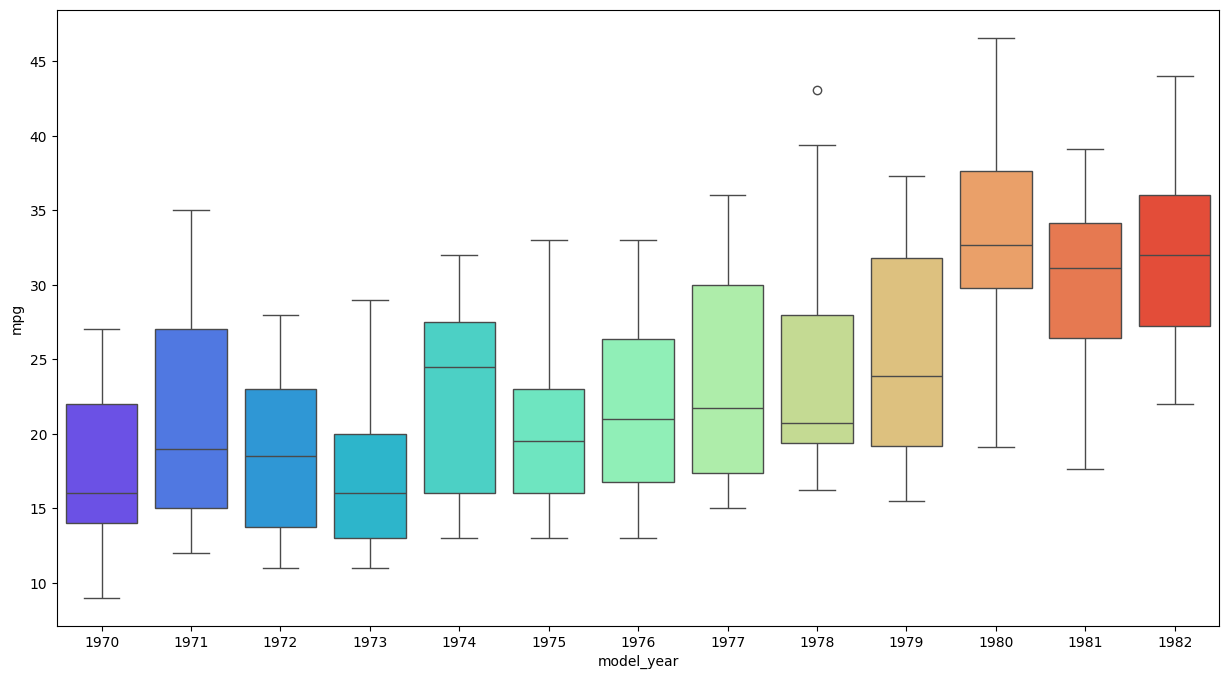

In [27]:
plt.figure(figsize=(15, 8))
sns.boxplot(x="model_year", y="mpg", data=df, palette="rainbow")
plt.show()

***Multivariate Analysis***

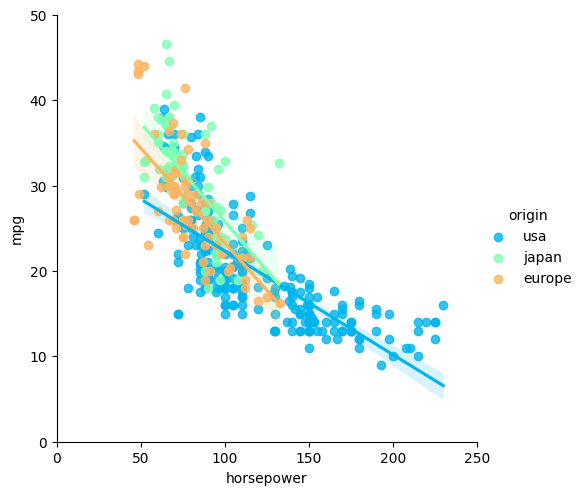

In [28]:
graph = sns.lmplot(x="horsepower", y="mpg", hue="origin", data=df, palette="rainbow")
graph.set(xlim=(0, 250))
graph.set(ylim=(0, 50))
plt.show()

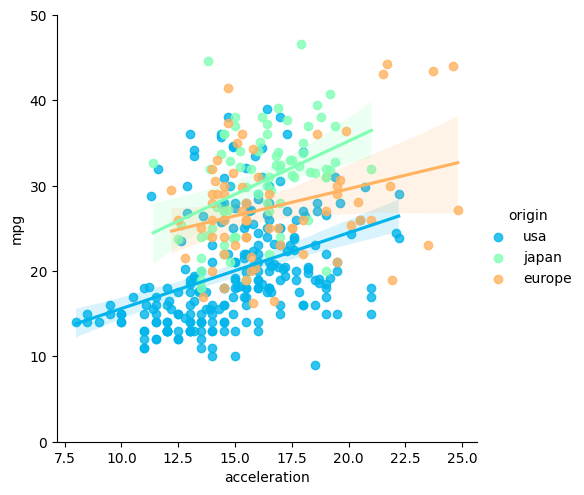

In [29]:
graph = sns.lmplot(x="acceleration", y="mpg", hue="origin", data=df, palette="rainbow")
graph.set(ylim=(0, 50))
plt.show()

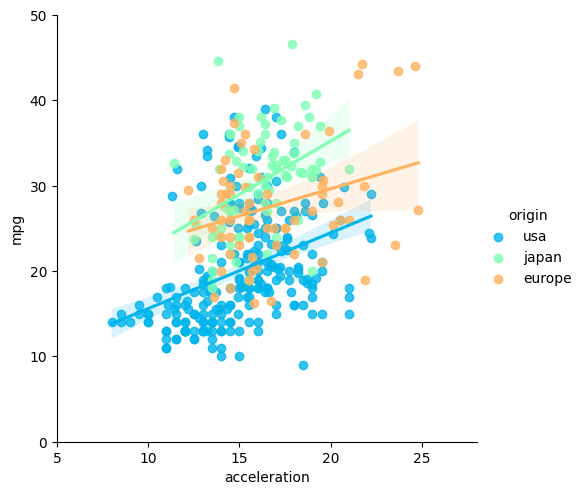

In [30]:
graph = sns.lmplot(x="acceleration", y="mpg", hue="origin", data=df, palette="rainbow")
graph.set(ylim=(0, 50))
graph.set(xlim=(5, 28))
plt.show()

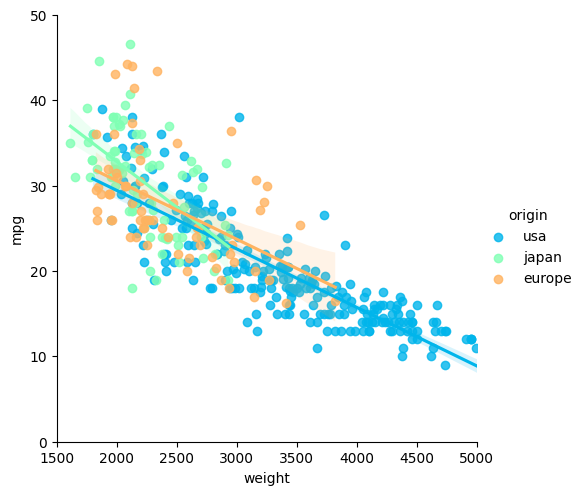

In [31]:
graph = sns.lmplot(x="weight", y="mpg", hue="origin", data=df, palette="rainbow")
graph.set(ylim=(0, 50))
graph.set(xlim=(1500, 5000))
plt.show()

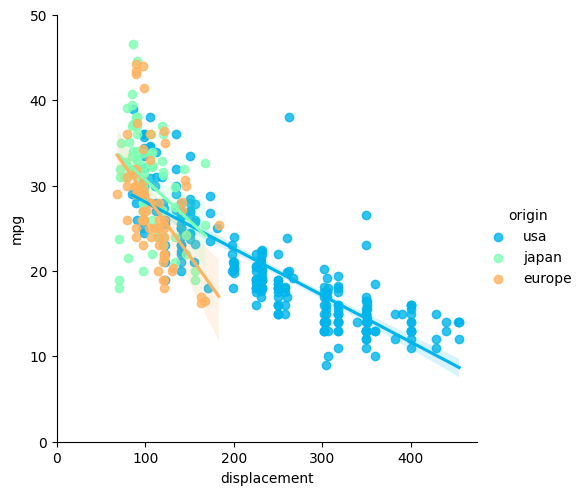

In [32]:
graph = sns.lmplot(x="displacement", y="mpg", hue="origin", data=df, palette="rainbow")
graph.set(ylim=(0, 50))
graph.set(xlim=(0, 475))
plt.show()

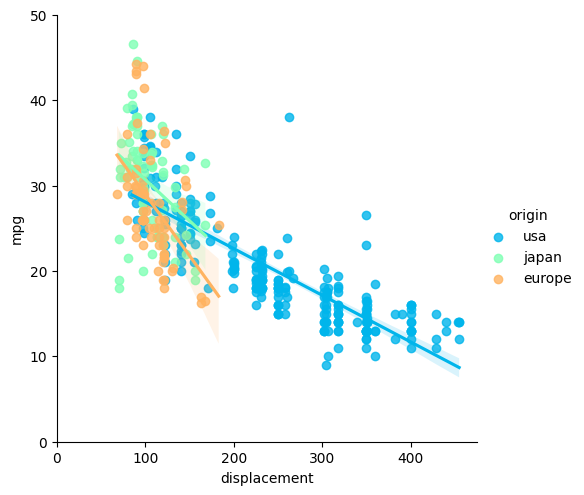

In [33]:
graph = sns.lmplot(x="displacement", y="mpg", hue="origin", data=df, palette="rainbow")
graph.set(ylim=(0, 50))
graph.set(xlim=(0, 475))
plt.show()

**Heatmap of Correlation Matrix**

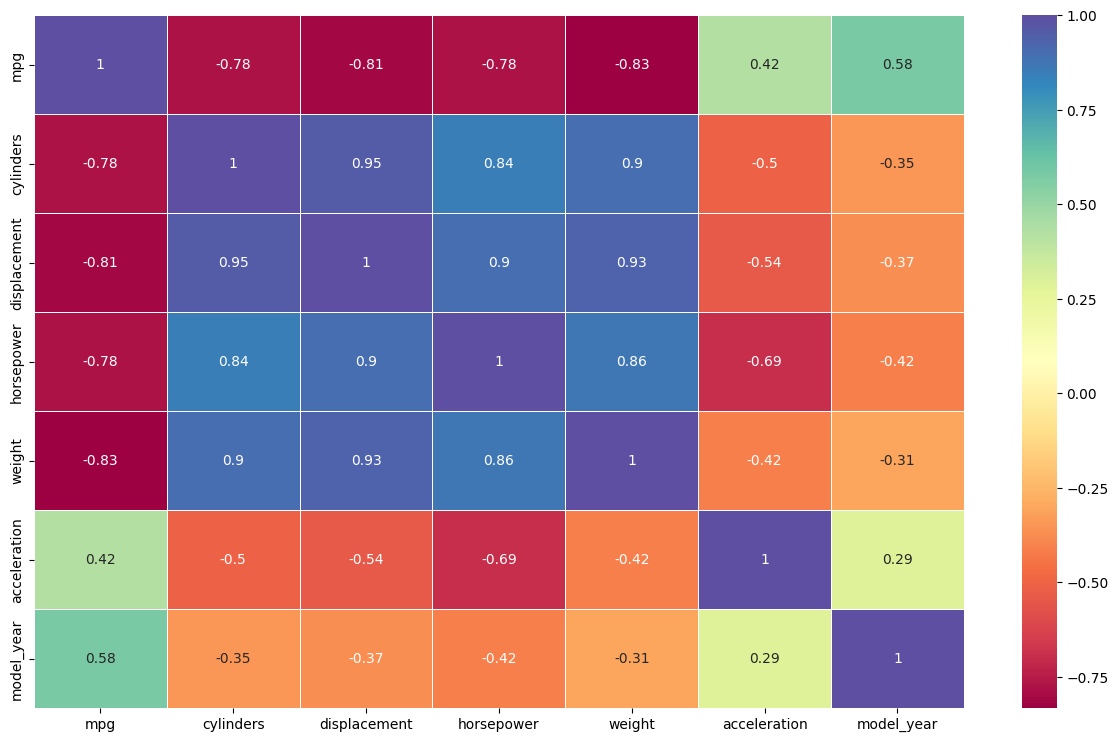

In [34]:
plt.figure(figsize=(15, 9))
sns.heatmap(df.corr(numeric_only=True), annot=True, linewidths=0.5, cmap="Spectral")
plt.show()

In [35]:
df.drop(["acceleration", "displacement"], axis=1, inplace=True)
df.head()

,mpg,cylinders,horsepower,weight,model_year,origin
0,18.0,8,130.0,3504,1970,usa
1,15.0,8,165.0,3693,1970,usa
2,18.0,8,150.0,3436,1970,usa
3,16.0,8,150.0,3433,1970,usa
4,17.0,8,140.0,3449,1970,usa


In [36]:
from datetime import datetime

In [37]:
today = datetime.today()
print(today)

2026-05-20 12:28:07.094690


In [38]:
print(today)

2026-05-20 12:28:07.094690


In [39]:
this_year = today.year
print(this_year)

2026


In [40]:
df["age"] = this_year - df.model_year
df.drop(["model_year"], axis=1, inplace=True)
df.head()

,mpg,cylinders,horsepower,weight,origin,age
0,18.0,8,130.0,3504,usa,56
1,15.0,8,165.0,3693,usa,56
2,18.0,8,150.0,3436,usa,56
3,16.0,8,150.0,3433,usa,56
4,17.0,8,140.0,3449,usa,56


In [41]:
df.origin.unique()

<StringArray>
['usa', 'japan', 'europe']
Length: 3, dtype: str

In [42]:
df = pd.get_dummies(df, columns=["origin"], drop_first=True)
df.head()

,mpg,cylinders,horsepower,weight,age,origin_japan,origin_usa
0,18.0,8,130.0,3504,56,False,True
1,15.0,8,165.0,3693,56,False,True
2,18.0,8,150.0,3436,56,False,True
3,16.0,8,150.0,3433,56,False,True
4,17.0,8,140.0,3449,56,False,True


**Modeling**

In [43]:
x = df.drop("mpg", axis=1)
y = df["mpg"]

In [44]:
from sklearn.model_selection import train_test_split

In [45]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [46]:
print(x_train)

     cylinders  horsepower  weight  age  origin_japan  origin_usa
260          6       110.0    3620   48         False        True
184          4        92.0    2572   50         False        True
174          6        97.0    2984   51         False        True
64           8       150.0    4135   54         False        True
344          4        64.0    1875   45         False        True
..         ...         ...     ...  ...           ...         ...
72           8       150.0    3892   54         False        True
107          6       100.0    2789   53         False        True
272          4        85.0    2855   48         False        True
352          4        65.0    2380   45         False        True
103          8       150.0    4997   53         False        True

[313 rows x 6 columns]


In [47]:
print(y_train)

260    18.6
184    25.0
174    18.0
64     15.0
344    39.0
       ... 
72     15.0
107    18.0
272    23.8
352    29.9
103    11.0
Name: mpg, Length: 313, dtype: float64


In [48]:
from sklearn.linear_model import LinearRegression
lm_model = LinearRegression()

In [49]:
lm_model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [51]:
print(lm_model.intercept_)

81.364229636065
